# 06 - Method Characterization and Control-Scene Audit

Characterizes what a matched filter actually selects on Tanager scenes, and audits
whether the intended control scene contains the plume its metadata implies.

### Why this notebook exists

A matched filter thresholded at mean + N sigma **always** returns pixels - a
continuous score distribution always has a tail. There is no "nothing here"
outcome. Detection alone is therefore not evidence, and the flagged pixels have to
be checked against something independent.

### What this notebook establishes

1. Scene-wide background statistics make the top of the score distribution fill
   with push-broom detector striping, not ground features.
2. Per-column background statistics remove that striping.
3. `20241121_183741_33_4001` (Casa Grande, AZ) carries the STAC note *"Plume A is
   a controlled release"* - but **the release is not inside this frame**. The note
   describes the collect, not the frame. Section 6 documents how to check this
   before spending time hunting a plume that is not there.

Positive-control validation moves to `07_positive_control.ipynb`, which uses a
scene with cataloged in-frame plumes.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../src")

import json
import numpy as np
import requests
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import label

from tanager_diagnostics import (
    run_validation, plot_validation,
    load_scene, swir_matrix, hitran_ch4_k,
    matched_filter_columnwise, score_at_coords,
    BAND_LO, BAND_HI,
)

SCENE_AZ = "../data/raw/20241121_183741_33_4001_basic_radiance.h5"
SCENE_TX = "../data/raw/20250205_175845_00_4001_basic_radiance.h5"
FIGDIR   = Path("../outputs/figures")
CACHE    = Path("../data/processed")
FIGDIR.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

for p in (SCENE_AZ, SCENE_TX):
    print(f"{'OK     ' if Path(p).exists() else 'MISSING'}  {p}")

OK       ../data/raw/20241121_183741_33_4001_basic_radiance.h5
OK       ../data/raw/20250205_175845_00_4001_basic_radiance.h5


## 1. Baseline — scene-wide matched filter

The method as originally built: one background mean and covariance for the whole
scene. Several minutes per scene.

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

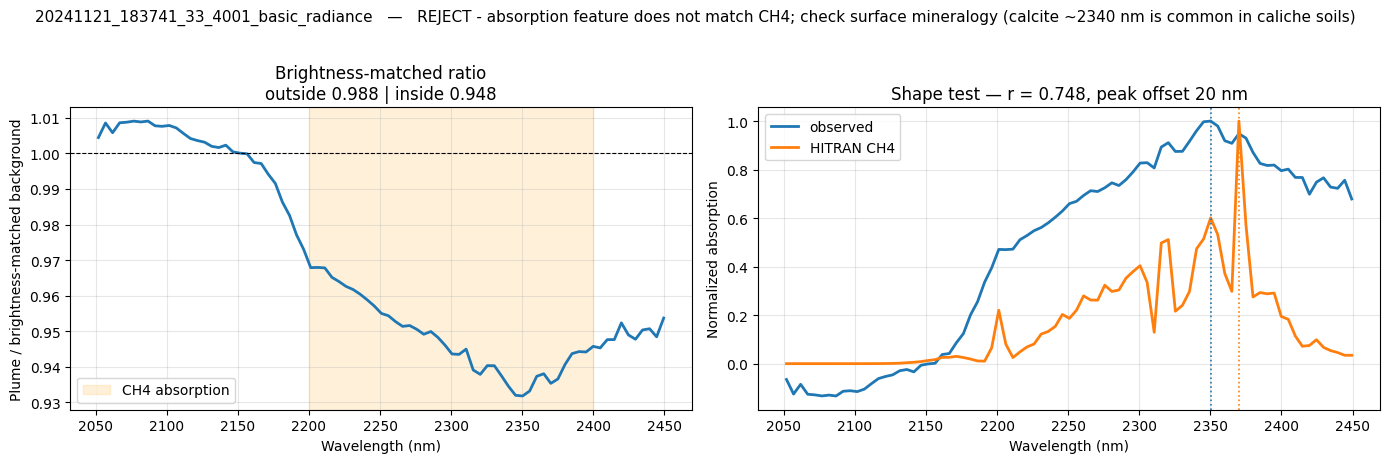

In [2]:
arizona = run_validation(SCENE_AZ)
plot_validation(arizona, FIGDIR / "validation_arizona.png")

Using ../data/reference/hitran

CH4
                     Lines parsed: 50571
{'air': 1.0}
11.860930 seconds elapsed for abscoef; nlines = 50571
VALIDATION — 20250205_175845_00_4001_basic_radiance
  Flagged pixels           : 106
  MF threshold             : 0.0785

  Brightness-matched control
    ratio outside CH4 bands: 0.996   (want ~1.00)
    ratio inside  CH4 bands: 0.964
    differential           : 0.0320

  HITRAN shape test
    correlation            : 0.715
    observed peak          : 2340 nm
    HITRAN peak            : 2370 nm
    offset                 : 30 nm   (want <15)

  VERDICT: REJECT - absorption feature does not match CH4; check surface mineralogy (calcite ~2340 nm is common in caliche soils)
Saved: ../outputs/figures/validation_permian.png


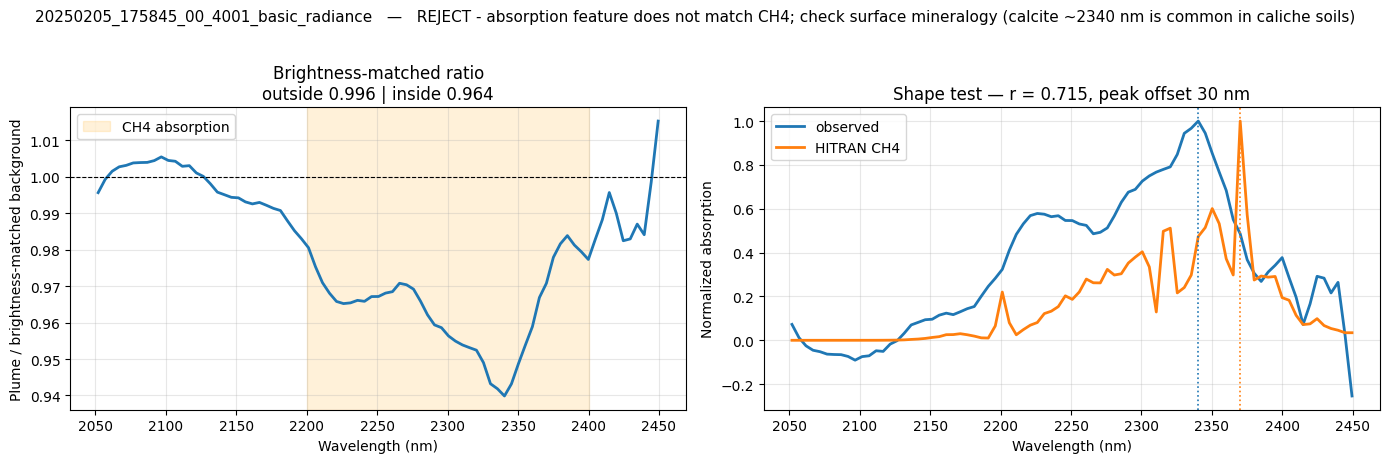

In [3]:
permian = run_validation(SCENE_TX)
plot_validation(permian, FIGDIR / "validation_permian.png")

**Read the two together.** Near-identical curves from two scenes in different
states, land cover and seasons — same peak position, same correlation, same smooth
featureless bowl — is a property of the *method*, not of either landscape.

Note the Permian verdict here is REJECT (r ~ 0.72, observed peak ~2340 nm against
HITRAN's 2370 nm, no line structure). That is the basis for treating the notebook
03-05 cluster results as invalid.

## 2. STAC metadata for the Casa Grande scene

In [4]:
import pystac

AZ_ITEM_URL = ("https://www.planet.com/data/stac/tanager-core-imagery/GHG-plumes/"
               "20241121_183741_33_4001/20241121_183741_33_4001.json")
item = pystac.Item.from_file(AZ_ITEM_URL)

for key in ("location_description", "notes", "plume_provider_ids", "gsd",
            "view:off_nadir", "view:sun_elevation", "light_haze_percent"):
    print(f"{key:24s}: {item.properties.get(key)}")

print("\nframe bbox [W, S, E, N]:", [round(v, 5) for v in item.bbox])
print("\nassets:")
for name in sorted(item.assets):
    print("  ", name)

location_description    : Casa Grande, Pinal County, Arizona, United States
notes                   : Controlled release plume example. Plume A is a conrolled release.
plume_provider_ids      : ['tan20241121t183727c00s4001-A']
gsd                     : 43.56
view:off_nadir          : 29.9
view:sun_elevation      : 36.4
light_haze_percent      : 66

frame bbox [W, S, E, N]: [-111.97834, 32.67943, -111.62306, 32.86348]

assets:
   basic_beta_udm
   basic_radiance_hdf5
   basic_sr_hdf5
   geolocation_array
   ortho_beta_udm
   ortho_ql_ch4
   ortho_radiance_hdf5
   ortho_sr_hdf5
   ortho_visual
   ql_ch4_json
   recent_monthly_mosaic
   thumbnail


Three things to carry forward:

- `notes` says a controlled release — **Section 6 tests whether it is in this frame.**
- `gsd` is ~43.6 m, not the 30 m nadir spec, because `view:off_nadir` is ~30 deg.
  Any pixel-area or emission-rate calculation must use the actual GSD.
- `light_haze_percent` is 66, which matters for detection sensitivity.

## 3. Where are the top-scoring pixels?

A plume is compact and elongated along the wind. Surface mineralogy is scattered
blobs. Push-broom striping is vertical lines spanning the full frame. Tightening
the threshold well past 2 sigma shows which dominates.

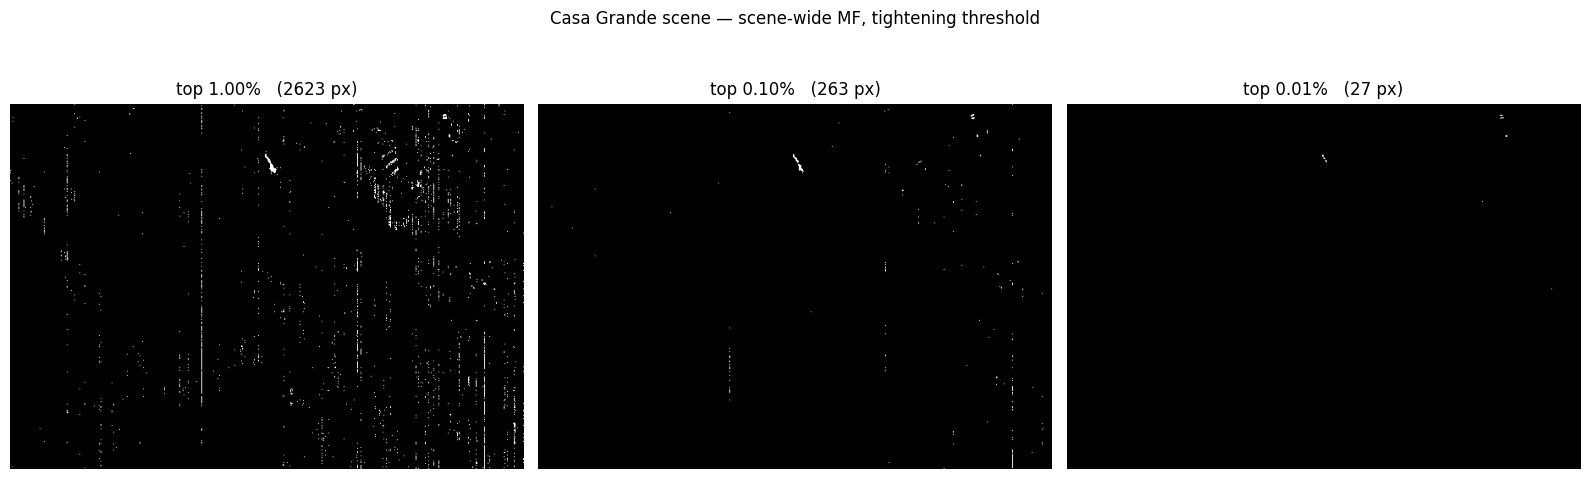

In [5]:
mf_scene = arizona.arrays["mf_map"]

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for a, pct in zip(ax, [99.0, 99.9, 99.99]):
    m = mf_scene > np.nanpercentile(mf_scene, pct)
    a.imshow(m, cmap="gray")
    a.set_title(f"top {100 - pct:.2f}%   ({int(m.sum())} px)")
    a.axis("off")
fig.suptitle("Casa Grande scene — scene-wide MF, tightening threshold", y=1.02)
fig.tight_layout()
fig.savefig(FIGDIR / "az_threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Column-wise matched filter

Tanager is a push-broom sensor: each cross-track sample is read out by its own
detector column with its own gain and dark offset. A scene-wide covariance treats
that fixed-pattern structure as signal. Estimating background statistics per
column removes it — standard for AVIRIS, EMIT and PRISMA.

Two implementation points, both of which were bugs in the first version:

- **The target is not unit-normalized.** With `t = -k * mu` the filter estimates
  absorption amplitude directly, so scores are comparable across columns.
  Normalizing per column rescales scores by `||k*mu_j||`, so bright columns score
  higher for identical gas and a global percentile threshold over-selects them.
  Measured on synthetic data with 3x gain difference: bright/dim score ratio was
  2.89 with normalization, 0.96 without.
- **Shrinkage is analytic Ledoit-Wolf per column**, not a fixed constant. Each
  column has only ~432 lines to estimate an 81x81 covariance, and the optimal
  intensity depends on that ratio.

In [6]:
# Load the control scene and build the target on its ACTUAL band centers.
rad_az, wl_az, lat_az, lon_az = load_scene(SCENE_AZ)
X_az, wl_swir_az, valid_az, shape_az = swir_matrix(rad_az, wl_az)

k_az = hitran_ch4_k(wl_swir_az)
if k_az is None:
    raise RuntimeError("hapi unavailable - run: pip install hitran-api")

print(f"SWIR bands: {len(wl_swir_az)}   k length: {len(k_az)}   (must match)")
print(f"HITRAN CH4 peak: {wl_swir_az[np.argmax(k_az)]:.1f} nm")

Using ../data/reference/hitran

CH4
                     Lines parsed: 50571
{'air': 1.0}
11.661349 seconds elapsed for abscoef; nlines = 50571
SWIR bands: 81   k length: 81   (must match)
HITRAN CH4 peak: 2370.1 nm


In [7]:
# Slow: one covariance inversion per detector column. Cached.
MF_COL_PATH = CACHE / "mf_columnwise_20241121.npy"

if MF_COL_PATH.exists():
    mf_col = np.load(MF_COL_PATH)
    print(f"loaded cache: {MF_COL_PATH}")
else:
    mf_col, _, info = matched_filter_columnwise(rad_az, wl_az, k_az, progress=True)
    np.save(MF_COL_PATH, mf_col)
    print(f"computed and cached: {MF_COL_PATH}")
    print("shrinkage mean/min/max: "
          f"{info['shrinkage_mean']:.3f} / {info['shrinkage_min']:.3f} / "
          f"{info['shrinkage_max']:.3f}")
    print(f"columns skipped: {info['columns_skipped']}")

print(f"shape {mf_col.shape} | valid {np.isfinite(mf_col).sum():,} px")

loaded cache: ../data/processed/mf_columnwise_20241121.npy
shape (432, 607) | valid 262,224 px


## 5. Scene-wide vs column-wise

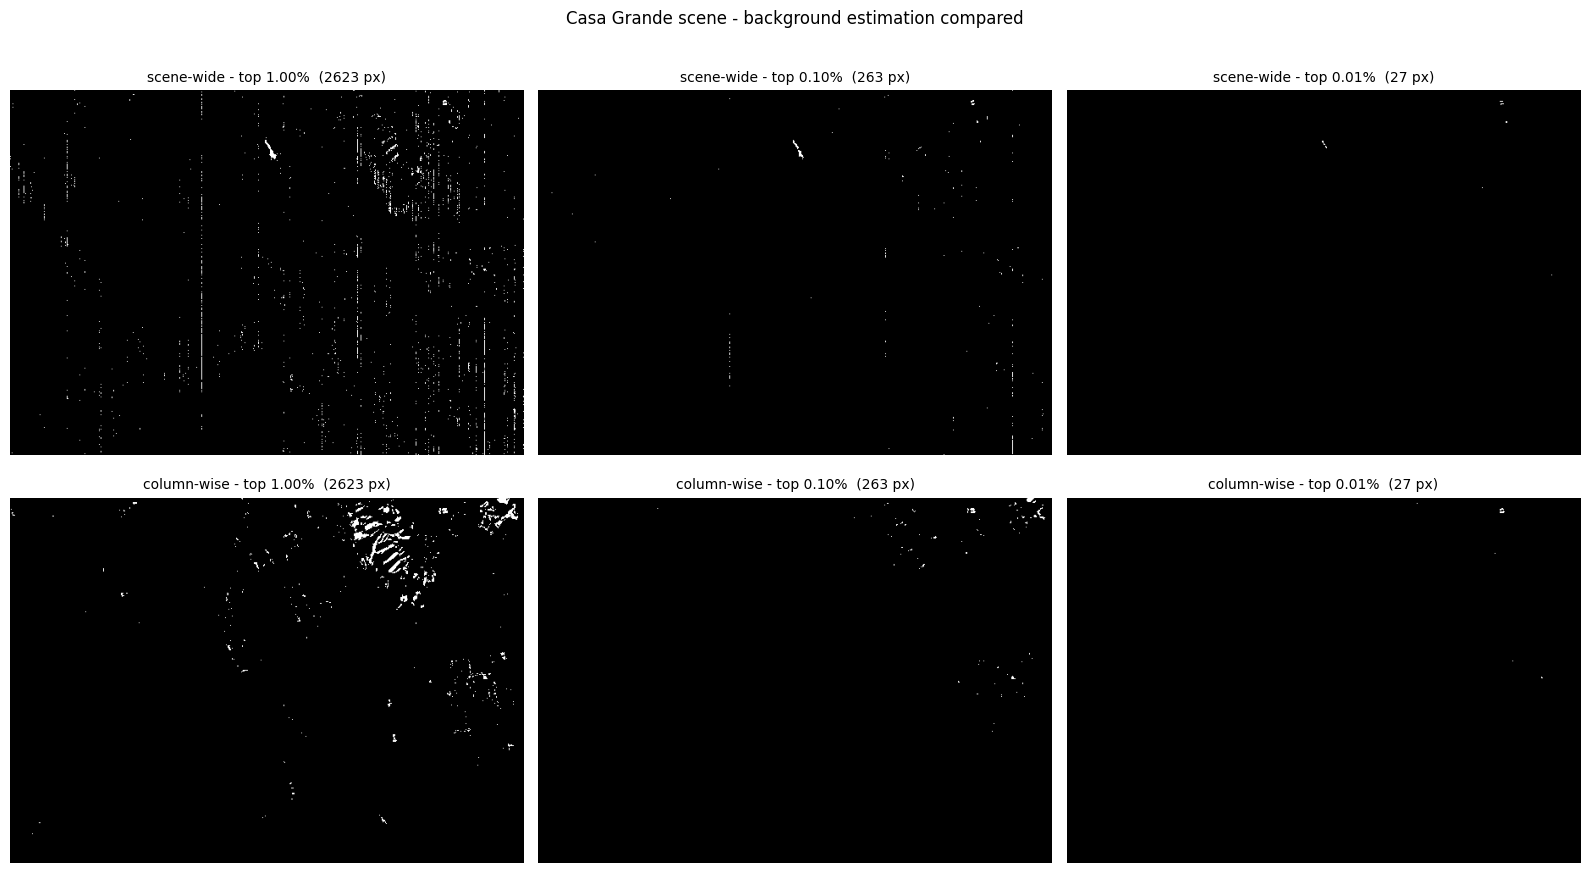

In [8]:
fig, ax = plt.subplots(2, 3, figsize=(16, 9))

for row, (m, lbl) in enumerate([(mf_scene, "scene-wide"), (mf_col, "column-wise")]):
    for col, pct in enumerate([99.0, 99.9, 99.99]):
        mask = m > np.nanpercentile(m, pct)
        ax[row, col].imshow(mask, cmap="gray")
        ax[row, col].set_title(f"{lbl} - top {100 - pct:.2f}%  ({int(mask.sum())} px)",
                               fontsize=10)
        ax[row, col].axis("off")

fig.suptitle("Casa Grande scene - background estimation compared", y=1.00)
fig.tight_layout()
fig.savefig(FIGDIR / "az_scenewide_vs_columnwise.png", dpi=150, bbox_inches="tight")
plt.show()

**What confirms the fix:** vertical striping drops out of the bottom row. What
remains is terrain — field boundaries and drainage patterns — which is a different
confound and the reason the shape test exists.

## 6. Control-scene audit: is the release actually in this frame?

The STAC `notes` field says "Plume A is a controlled release". That is a statement
about the **collect**, not necessarily about this **frame**. Three independent
checks follow. Any one of them is enough; together they are conclusive.

### 6a. Planet's own CH4 quicklook products for this frame

If Planet detected a plume in this frame, `ql_ch4_json` carries its geometry.

In [9]:
ql = item.assets.get("ql_ch4_json")
if ql is None:
    print("No ql_ch4_json asset on this item.")
else:
    r = requests.get(ql.href, timeout=30)
    r.raise_for_status()
    fc = r.json()
    feats = fc.get("features", [])
    print(f"ql_ch4_json type    : {fc.get('type')}")
    print(f"features in frame   : {len(feats)}")
    if not feats:
        print("\n=> EMPTY FeatureCollection. Planet detected no plume in this frame.")
    else:
        for f in feats:
            print("  ", f.get("properties"))

ql_ch4_json type    : FeatureCollection
features in frame   : 0

=> EMPTY FeatureCollection. Planet detected no plume in this frame.


### 6b. Carbon Mapper's catalog for this footprint

Note the API quirk: the `plume_names` parameter is silently ignored — it returns
unfiltered results, which is easy to mistake for a match. Query by `bbox` instead,
passed as four repeated params in W, S, E, N order.

In [10]:
W, S, E, N = item.bbox
PAD = 0.05   # degrees, ~5 km - wide enough to catch a plume just outside

resp = requests.get(
    "https://api.carbonmapper.org/api/v1/catalog/plumes/annotated",
    params=[("bbox", W - PAD), ("bbox", S - PAD),
            ("bbox", E + PAD), ("bbox", N + PAD),
            ("limit", 100), ("offset", 0)],
    timeout=30,
)
resp.raise_for_status()
items = resp.json().get("items", [])
print(f"{len(items)} cataloged plume(s) within {PAD} deg of the frame\n")

targets = []
for p in items:
    lon_p, lat_p = p["geometry_json"]["coordinates"]      # GeoJSON is [lon, lat]
    inside = (W <= lon_p <= E) and (S <= lat_p <= N)
    print(f"  {p.get('plume_id')}")
    print(f"    lat, lon      : {lat_p:.5f}, {lon_p:.5f}")
    print(f"    inside frame  : {inside}")
    print(f"    emission      : {p.get('emission_auto')} kg/hr")
    print(f"    gas           : {p.get('gas')}")
    targets.append((p.get("plume_id"), lat_p, lon_p))

71 cataloged plume(s) within 0.05 deg of the frame

  tan20260727t193131c18s4001-A
    lat, lon      : 32.90458, -111.78825
    inside frame  : False
    emission      : 112776.39467562345 kg/hr
    gas           : CO2
  tan20260720t193159c02s4001-B
    lat, lon      : 32.90375, -111.78897
    inside frame  : False
    emission      : 190617.76112871798 kg/hr
    gas           : CO2
  tan20260713t193216c94s4001-A
    lat, lon      : 32.90406, -111.78924
    inside frame  : False
    emission      : None kg/hr
    gas           : CO2
  tan20260706t193247c83s4001-A
    lat, lon      : 32.90380, -111.78914
    inside frame  : False
    emission      : 109826.30095952332 kg/hr
    gas           : CO2
  tan20260629t193625c96s4001-A
    lat, lon      : 32.90412, -111.78809
    inside frame  : False
    emission      : 55659.27844552685 kg/hr
    gas           : CO2
  tan20260627t192506c05s4001-A
    lat, lon      : 32.90404, -111.78900
    inside frame  : False
    emission      : 1257.32651

### 6c. Where does the nearest pixel land?

If the nearest pixel to a plume is on row 0 or the last row, the plume is off the
edge and the "nearest pixel" is just the closest point on the boundary.

In [11]:
if not targets:
    print("No cataloged plumes to locate.")
else:
    rows = score_at_coords(mf_col, lat_az, lon_az, targets)
    for r_ in rows:
        print(f"{r_['label']}")
        print(f"  nearest pixel : row {r_['row']}, col {r_['col']}  "
              f"of {mf_col.shape[0]}x{mf_col.shape[1]}")
        print(f"  offset        : {r_['offset_km']} km")
        print(f"  MF score      : {r_['mf_score']}")
        print(f"  percentile    : {r_['percentile']}")
        print(f"  in frame      : {r_['in_frame']}")

    edge = [r_ for r_ in rows if not r_["in_frame"]]
    if edge:
        print(f"\n=> {len(edge)} of {len(rows)} plume(s) fall outside the frame.")
        print("   A nearest pixel on row 0 means the release is beyond the top edge.")

tan20260727t193131c18s4001-A
  nearest pixel : row 0, col 270  of 432x607
  offset        : 6.642 km
  MF score      : 0.2412
  percentile    : 93.362
  in frame      : False
tan20260720t193159c02s4001-B
  nearest pixel : row 0, col 269  of 432x607
  offset        : 6.541 km
  MF score      : 0.242
  percentile    : 93.416
  in frame      : False
tan20260713t193216c94s4001-A
  nearest pixel : row 0, col 268  of 432x607
  offset        : 6.569 km
  MF score      : 0.2432
  percentile    : 93.475
  in frame      : False
tan20260706t193247c83s4001-A
  nearest pixel : row 0, col 268  of 432x607
  offset        : 6.542 km
  MF score      : 0.2432
  percentile    : 93.475
  in frame      : False
tan20260629t193625c96s4001-A
  nearest pixel : row 0, col 270  of 432x607
  offset        : 6.594 km
  MF score      : 0.2412
  percentile    : 93.362
  in frame      : False
tan20260627t192506c05s4001-A
  nearest pixel : row 0, col 268  of 432x607
  offset        : 6.57 km
  MF score      : 0.2432
 

1 on scene date, 70 other dates


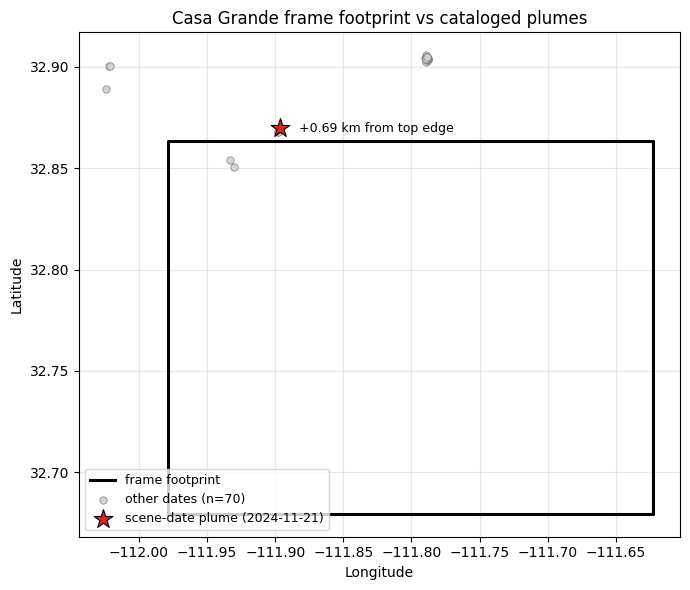

In [13]:
from datetime import datetime

def plume_date(p):
    """Date for a catalog entry, parsed from the plume id if no timestamp field."""
    for key in ("scene_timestamp", "datetime", "observed_at"):
        v = p.get(key)
        if v:
            try:
                return datetime.fromisoformat(str(v).replace("Z", "+00:00")).date()
            except ValueError:
                pass
    pid = str(p.get("plume_id", ""))
    for i in range(len(pid) - 7):
        c = pid[i:i+8]
        if c.isdigit():
            try:
                return datetime.strptime(c, "%Y%m%d").date()
            except ValueError:
                continue
    return None


scene_date = item.datetime.date()
W, S, E, N = item.bbox

same_day, other_day = [], []
for p in items:
    lon_p, lat_p = p["geometry_json"]["coordinates"]
    (same_day if plume_date(p) == scene_date else other_day).append(
        (p.get("plume_id"), lat_p, lon_p))

print(f"{len(same_day)} on scene date, {len(other_day)} other dates")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([W, E, E, W, W], [S, S, N, N, S], "k-", lw=2.2,
        label="frame footprint", zorder=4)

if other_day:
    ax.scatter([c for _, _, c in other_day], [b for _, b, _ in other_day],
               s=28, marker="o", c="lightgray", edgecolors="gray",
               linewidths=0.5, zorder=3,
               label=f"other dates (n={len(other_day)})")

for pid, plat, plon in same_day:
    ax.scatter(plon, plat, s=200, marker="*", c="tab:red",
               edgecolors="k", linewidths=0.8, zorder=6,
               label=f"scene-date plume ({scene_date})"
               if (pid, plat, plon) == same_day[0] else None)
    ax.annotate(f"  {(plat - N)*111.32:+.2f} km from top edge",
                (plon, plat), xytext=(8, 0), textcoords="offset points",
                fontsize=9, va="center", zorder=7)

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Casa Grande frame footprint vs cataloged plumes")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGDIR / "az_frame_vs_plume.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion

| Check | Result |
|---|---|
| Planet `ql_ch4_json` for the frame | empty FeatureCollection |
| Carbon Mapper catalog | plume ~0.7 km north of the frame's top edge |
| Nearest pixel to the plume | row 0 — on the boundary |

**The Casa Grande frame does not contain the controlled release.** The plume ID
timestamp (`183727`) is the collect start; the release was imaged by an adjacent
frame that is not in the open catalog.

This matters beyond this project. The STAC `notes` field is accurate about the
collect and misleading about the frame, and nothing in the item metadata flags the
difference. Anyone building on this catalog can lose substantial time hunting a
plume in the wrong scene. The check is cheap: read `ql_ch4_json`, and query Carbon
Mapper by bbox rather than by plume name.

**Consequence for this project:** no positive control has been established, so the
detection chain remains unvalidated. The REJECT verdicts in Section 1 are
therefore *uncalibrated* — they may be correct, but nothing yet shows the method
would ACCEPT a real plume.

**Next:** `07_positive_control.ipynb` uses `20241004_081921_28_4001` (Iraq, 12
cataloged in-frame plumes) to measure what percentile known plumes reach, and to
calibrate the `_verdict` thresholds on held-out plumes.